In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import inspect

%matplotlib inline

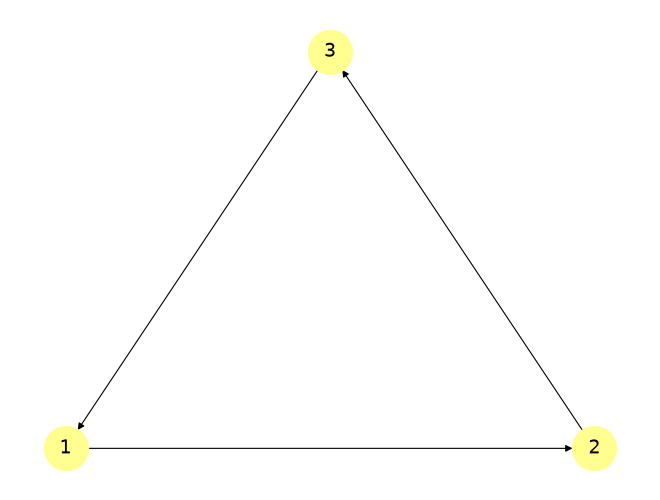

In [4]:
# Ejemplo: Grafos dirigidos
triangle_graph = nx.DiGraph([(1,2), (2,3), (3,1)])
nx.draw_planar(
    triangle_graph,
    with_labels=True,
    node_size=1000,
    node_color="#ffff8f",
    width=0.8,
    font_size=14,
)

## Definición
Un digrafo es un grafo compuesto de un conjunto de vértices conectado por aristas dirigidos comunmente llamados arcos. Los vértices tienen direccionalidad, difernte a los grafos no dirigidos donde semánticamente no existe noción de dirección. Los DAG van más allá incluyendo la propiedad de que no tienen ciclos entre ellos.

In [5]:
# Ejemplo
clothing_graph = nx.read_graphml(f"data/clothing_graph.graphml")

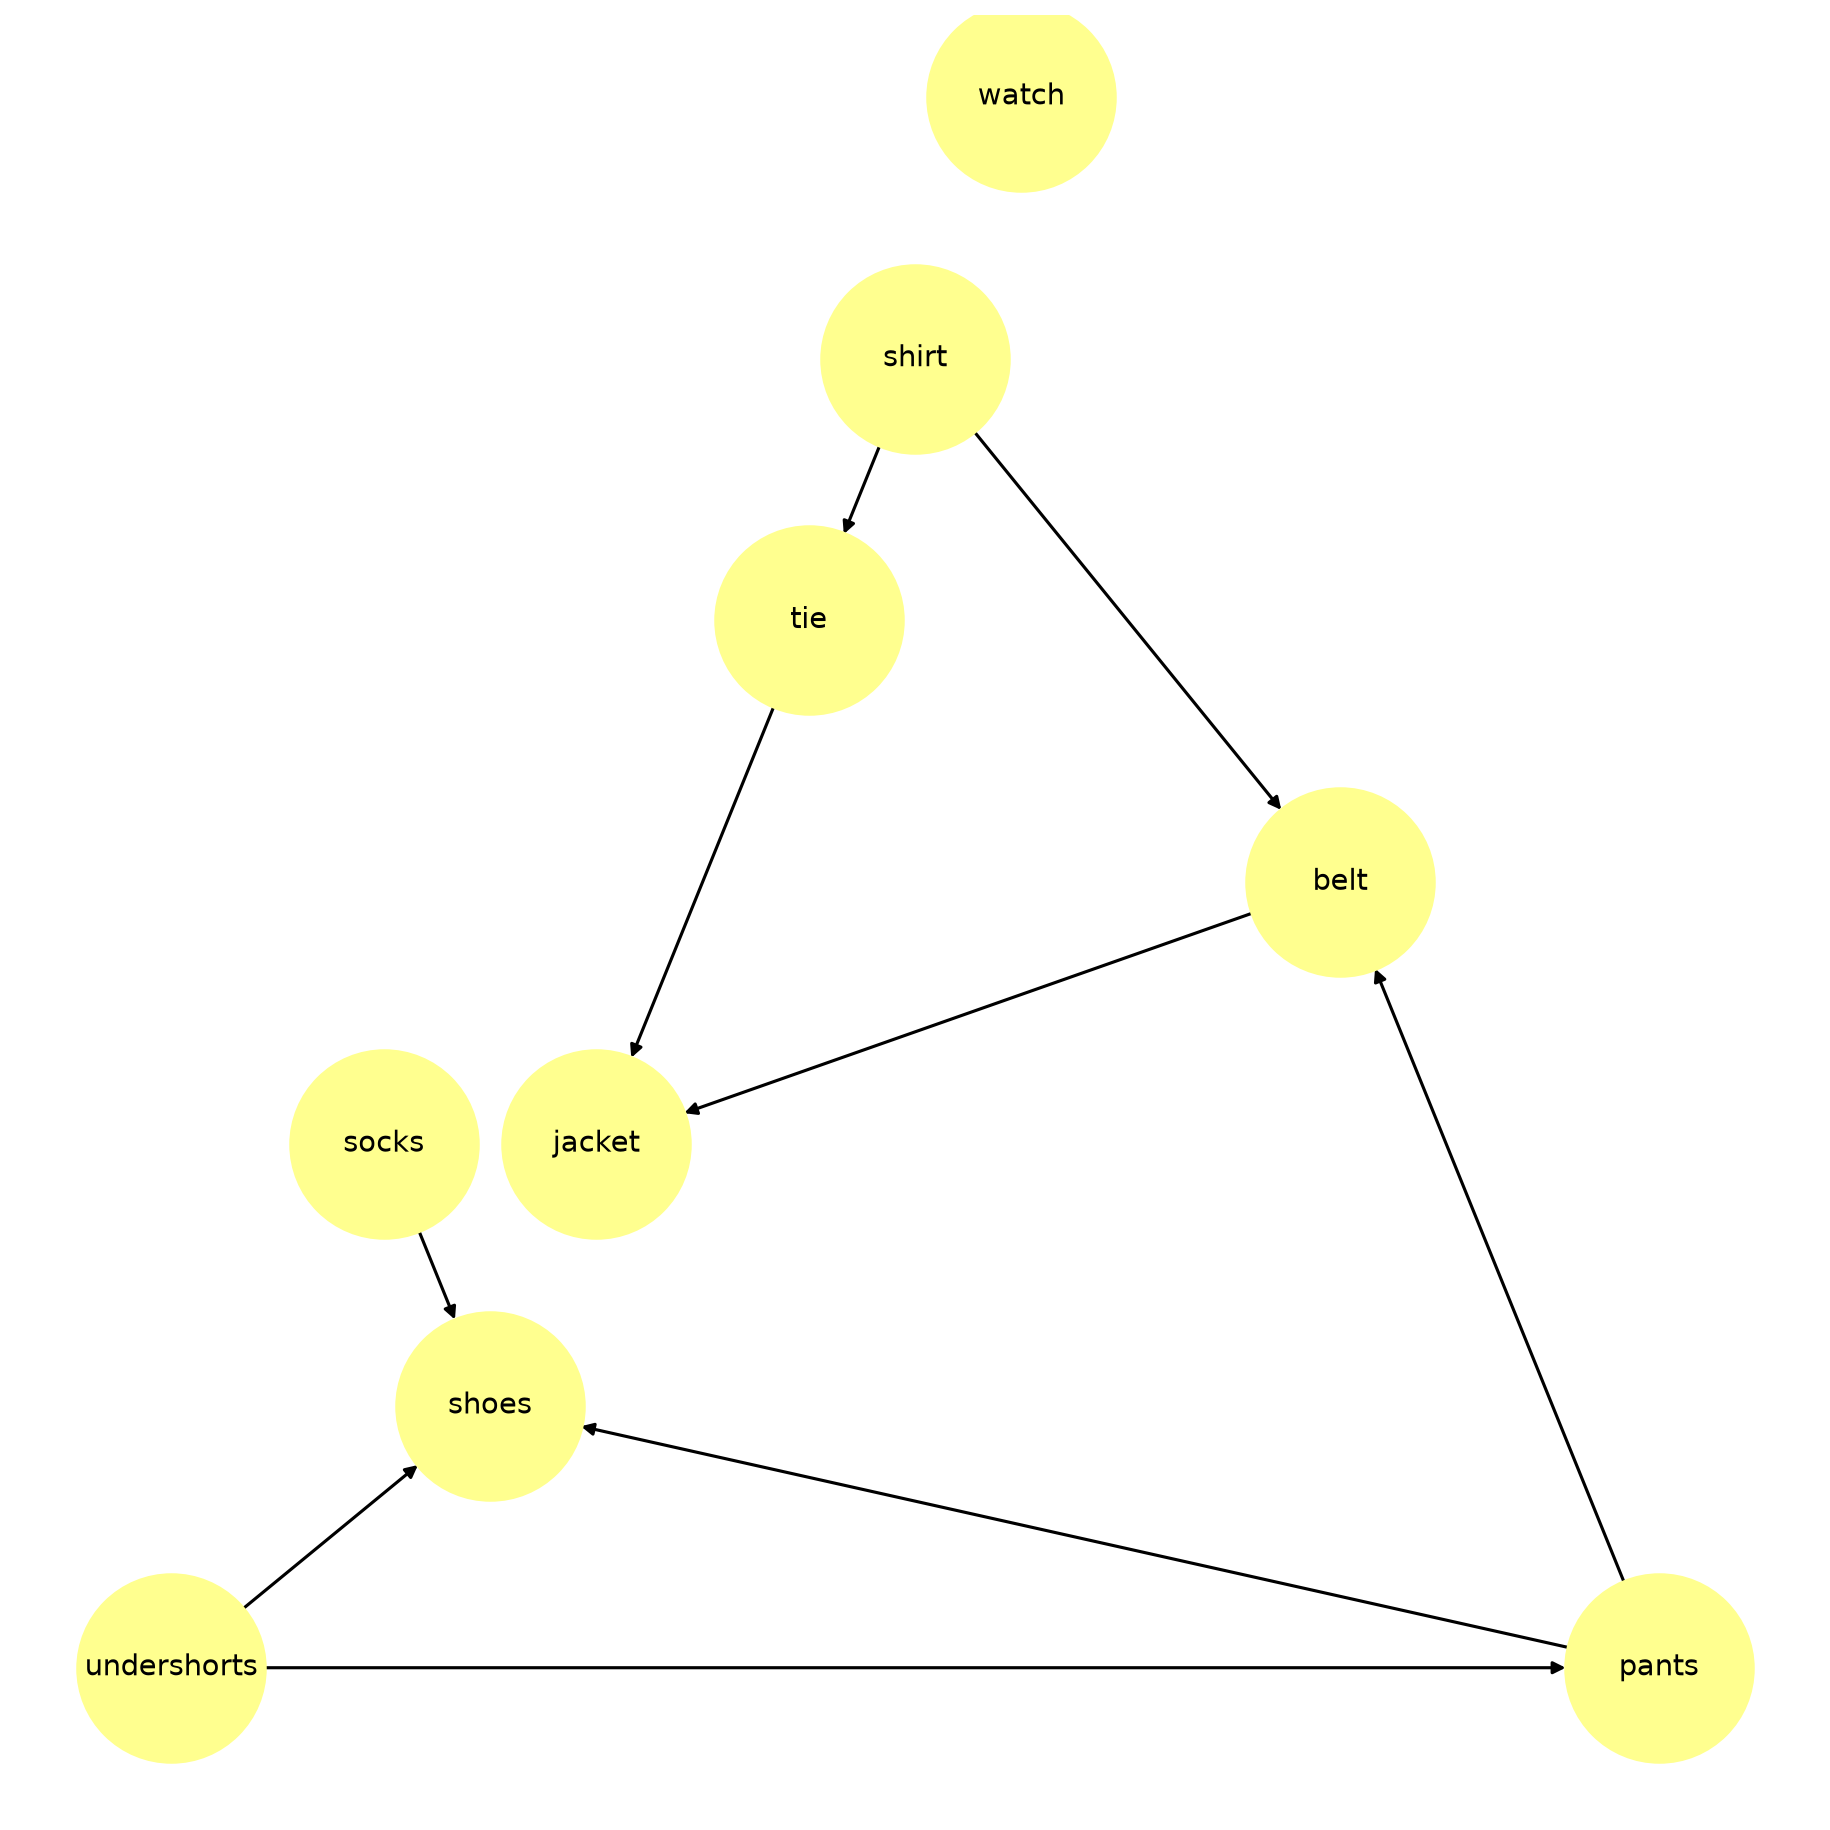

In [6]:
plt.figure(figsize=(12,12), dpi=150)
nx.draw_planar(
    clothing_graph,
    arrowsize=12,
    with_labels=True,
    node_size=8000,
    node_color="#ffff8f",
    linewidths=2.0,
    width=1.5,
    font_size=14
)

In [8]:
# En este ejemplo, el grafo es un DAG
nx.is_directed_acyclic_graph(clothing_graph)

True

In [10]:
# El anterior no lo era
nx.is_directed_acyclic_graph(triangle_graph)

False

In [11]:
# El ciclo en cuestión
nx.find_cycle(triangle_graph)

[(1, 2), (2, 3), (3, 1)]

## Aplicaciones
Las representaciones de ordenamientos parciales con DAGs tienen muchas aplicaciones en scheduling de sistemas de tareas con restricciones de ordenamiento. Especialmente en colecciones de objetos que se deben actualizar: calcular el orden de celdas de un excel a ordenar luego de que una ha sido cambiada, identificar cuales archivos de un software se deben actualizar luego de que el código fuente ha sido cambiado. Para esto se usa un grafo de dependencias, que tiene un vértice para cada objeto a ser actualizado y una arista conectando dos objetos cuando uno debe ser actualizado antes que el otro. En estos grafos, un ciclo es llamado una dependencia circular, que en general no es aceptada. Si hubiese una de estas, no habría manera de schedulear las tareas consistentemente. Si no se tienen, es un DAG.

Se usan también para representar redes de elementos procesadores. En este caso, los datos entran a un elemento procesador a través de sus vértices de entrada y salen mediante los vértices de salida. 

In [12]:
# Ordenamiento topológico
list(nx.topological_sort(clothing_graph))

['undershorts',
 'shirt',
 'socks',
 'watch',
 'pants',
 'tie',
 'belt',
 'shoes',
 'jacket']

## Aplicaciones
En scheduling es una secuencia de tareas basada en sus dependencias. Las tareas son los vértices y existe una arista de $u$ a $v$ si la tarea $u$ debe ser completada antes de la tarea $v$ empezada. El ordenamiento topológico nos da un orden en que se deben ejecutar las taresas. 
## Definición
Un ordenamiento topológico de un DAG $G = (V,E)$ es un ordenamiento lineal de todos sus vértices de manera en que si $G$ contiene una arista $(u,v)$, entonces $u$ aparece antes que $v$ en el ordenamiento.
No es posible si se tiene un ciclo. Se puede ver como que es un ordenamineto de los vértices en una línea horizontal donde todas las aristas van de izquierda a derecha. NetworkX utiliza el algoritmo de Kahn para esto. Sirve en multigrafos

In [17]:
multigraph = clothing_graph.is_multigraph()

In [19]:
print(multigraph)

False


In [34]:
# Implementación (no necesario leer, permite ver cuales tareas se puede hacer paralelamente)
def topological_generations(G):
    if not G.is_directed():
        raise nx.NetworkXError("Topological sort not defined on undirected graphs.")

    multigraph = G.is_multigraph()
    indegree_map = {v: d for v, d in G.in_degree() if d > 0}
    zero_indegree = [v for v, d in G.in_degree() if d == 0]

    while zero_indegree:
        this_generation = zero_indegree
        zero_indegree = []
        for node in this_generation:
            if node not in G:
                raise RuntimeError("Graph changed during iteration")
            for child in G.neighbors(node):
                try:
                    # En multigrafos se restan todas las aristas paralelas entre node y child
                    indegree_map[child] -= len(G[node][child]) if multigraph else 1
                except KeyError as err:
                    raise RuntimeError("Graph changed during iteration") from err
                if indegree_map[child] == 0:
                    zero_indegree.append(child)
                    del indegree_map[child]
        yield this_generation

    if indegree_map:
        raise nx.NetworkXUnfeasible(
            "Graph contains a cycle or graph changed during iteration"
        )

In [35]:
# Generaciones (niveles) del ordenamiento topológico
list(topological_generations(clothing_graph))

[['undershorts', 'shirt', 'socks', 'watch'],
 ['pants', 'tie'],
 ['belt', 'shoes'],
 ['jacket']]

In [37]:
list(nx.topological_generations(clothing_graph)) # la función de NetworkX

[['undershorts', 'shirt', 'socks', 'watch'],
 ['pants', 'tie'],
 ['belt', 'shoes'],
 ['jacket']]